In [22]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix


In [23]:
df = pd.read_csv('synthetic_text_data.csv')
df.head()

,text,label
0,Artificial intelligence is advancing in health...,Technology
1,Football fans are excited about the upcoming W...,Sports
2,New policies regarding climate change have spa...,Politics
3,The latest blockbuster movie has shattered box...,Entertainment
4,Quantum computing promises to revolutionize in...,Technology


In [24]:
df['label'].value_counts()

label
Technology       30
Politics         21
Entertainment    19
Sports           15
Name: count, dtype: int64

In [25]:
df['text'].unique()

array(['Artificial intelligence is advancing in healthcare with numerous applications emerging.',
       'Football fans are excited about the upcoming World Cup, with teams preparing intensively.',
       'New policies regarding climate change have sparked a heated debate in the political arena.',
       'The latest blockbuster movie has shattered box office records and is trending worldwide.',
       'Quantum computing promises to revolutionize industries, from finance to pharmaceuticals.',
       'Political debates are becoming more heated as elections approach in several countries.',
       'Tech companies are investing heavily in artificial intelligence to improve their products.',
       'The summer Olympics are fast approaching, and athletes are training harder than ever.',
       'Music festivals are back this year with global headliners performing in major cities.',
       'The rise of self-driving cars is changing the transportation landscape globally.',
       'Cybersecurity 

In [26]:
X = df['text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
vectorizer = CountVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

In [28]:
model = MultinomialNB()
model.fit(X_train_vectorized, y_train)

MultinomialNB()

In [29]:
y_pred = model.predict(X_test_vectorized)

Accuracy: 88.23529411764706%


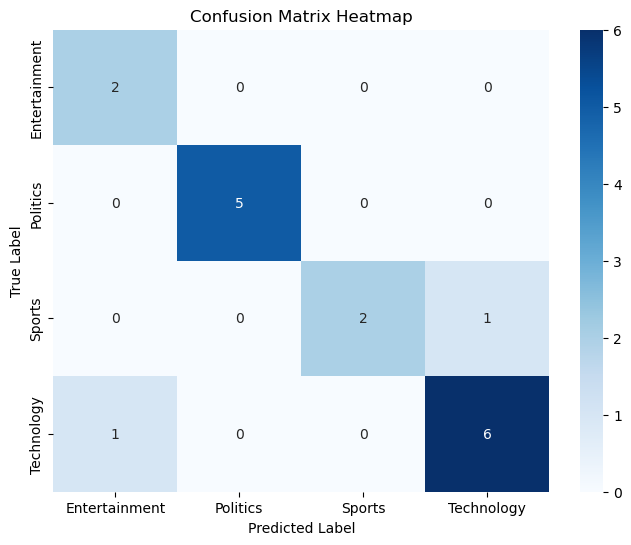

In [30]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy *100}%')

class_labels = np.unique(y_test)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [31]:
# # safe the model and vectorizer
# import pickle
# pickle.dump(model, open('model.pkl', 'wb'))
# pickle.dump(vectorizer, open('vectorizer.pkl', 'wb'))

In [32]:
import joblib

joblib.dump(model, 'text_classifier_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

['vectorizer.pkl']